# Training Loss Analysis
This notebook loads loss history data and visualizes training vs validation losses with dual-axis scaling.

## Section 1: Import Required Libraries

In [36]:
import json
import matplotlib.pyplot as plt
import numpy as np

## Section 2: Load and Parse JSON Data

In [37]:
# Load loss history from JSON file
with open('loss_history.json', 'r') as f:
    loss_data = json.load(f)

train_losses = loss_data['train_losses']
val_losses = loss_data['val_losses']

print(f"Loaded {len(train_losses)} training losses")
print(f"Loaded {len(val_losses)} validation losses")

Loaded 500 training losses
Loaded 500 validation losses


## Section 3: Prepare Data for Plotting

In [38]:
# Create x-axis data (epoch/batch indices)
epochs = np.arange(len(train_losses))

# Get first values for scaling alignment
train_first = train_losses[0]
val_first = val_losses[0]

# Calculate scaling factor to align first points
scale_factor = train_first / val_first

print(f"First training loss: {train_first:.4f}")
print(f"First validation loss: {val_first:.4f}")
print(f"Scaling factor: {scale_factor:.4f}")

First training loss: 3.5446
First validation loss: 1.8604
Scaling factor: 1.9052


## Section 4: Create Dual-Axis Plot

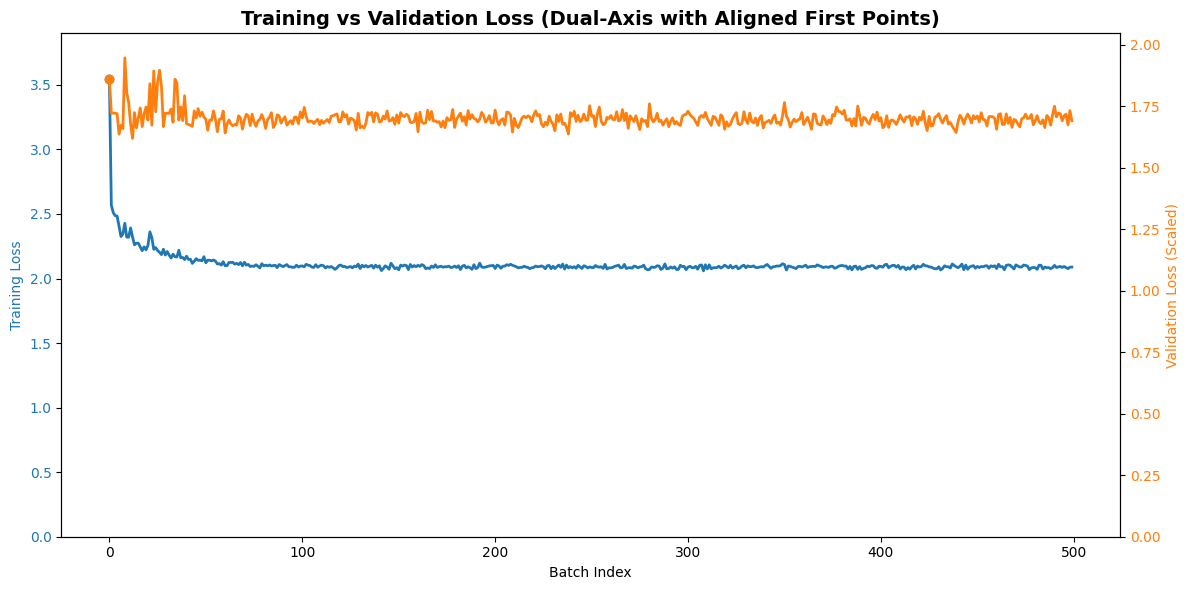

In [55]:
# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot training loss on left axis (blue)
color = 'tab:blue'
ax1.set_xlabel('Batch Index')
ax1.set_ylabel('Training Loss', color=color)
line1 = ax1.plot(epochs, train_losses, color=color, label='Training Loss', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.plot(0, train_first, 'o', color=color)

# Create secondary y-axis for validation loss
ax2 = ax1.twinx()

# Scale validation losses to align first points with training losses
val_losses_scaled = [v * scale_factor for v in val_losses]

# Plot validation loss on right axis (orange), with scaled values
color = 'tab:orange'
ax2.set_ylabel('Validation Loss (Scaled)', color=color)
line2 = ax2.plot(epochs, val_losses, color=color, label='Validation Loss', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)
ax2.plot(0, val_first, 'o', color=color)

# Add 5% padding to max values for visibility
padding = 0.1
ax1.set_ylim([0, train_losses[0] * (1 + padding)])
ax2.set_ylim([0, val_losses[0] * (1 + padding)])

plt.title('Training vs Validation Loss (Dual-Axis with Aligned First Points)', fontsize=14, fontweight='bold')
fig.tight_layout()

## Section 5: Display the Plot with Legend

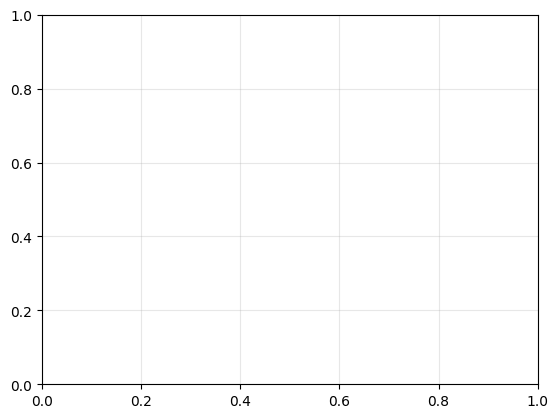


Plot Analysis:
  - Left axis (Training): 2.0593 to 3.5446
  - Right axis (Validation, scaled): 3.0850 to 3.7093
  - First points aligned at y ≈ 3.5446


In [40]:
# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=11)

# Display the plot
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nPlot Analysis:")
print(f"  - Left axis (Training): {train_min:.4f} to {train_max:.4f}")
print(f"  - Right axis (Validation, scaled): {val_min * scale_factor:.4f} to {val_max * scale_factor:.4f}")
print(f"  - First points aligned at y ≈ {train_first:.4f}")